To reduce overfitting and maintain high generalization ability, we learned about ensemble learning methods, and therefore our choice remained on XGBoost. Gradient boosting of this model builds decision trees sequentially, where each subsequent tree corrects the errors of the previous ones. We chose this implementation because of its optimization – **histogram-based binning** (sorting), which processes 227 features with sparse vectors, has support for missing values ​​and is robust to unscaled data. Regularization does not allow the model to memorize the training data.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('data_for_ML-tgShifted.parquet')

df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]: 
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (644060, 227): 2022-03-03 00:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


n_estimators=300(Number of iterations); we chose 300, a smaller number of trees would not allow the algorithm to learn all 227 features, and a larger number could lead to the model simply memorizing the training data (overfitting)

max_depth=6(Tree depth); this is a standard but very efficient value. A depth of 6 allows the model to consider the interaction of up to 6 different features at the same time (for example: region + temperature + news + 24h lag + day of the week + pressure)

subsample=0.8 and colsample_bytree=0.8(Regularization by Randomness); we deliberately forced each individual tree to see only 80% of the data and 80% of the features

scale_pos_weight(Class balancing); in our dataset, there are significantly more peaceful hours (class 0) than alarm hours (class 1)

We focused on finding the perfect balance between learning rate and the model's ability to correct errors. Our search included the following values: [0.01, 0.05, 0.1], and for quality assessment we chose the ROC-AUC metric, which best reflects the model's ability to discriminate threats.




In [4]:
for lr in [0.01, 0.05, 0.1]:
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=lr, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"lr={lr} and ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

lr=0.01 → ROC-AUC: 0.8709
lr=0.05 → ROC-AUC: 0.8737
lr=0.1 → ROC-AUC: 0.8705


In [5]:
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

For practical implementation of the risk minimization strategy, we abandoned the standard classification threshold of $0.5$. A threshold of $0.3$ was implemented in the inference script. This allowed the system to signal a threat even at a moderate level of probability, which directly ensured a high completeness index.

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_03 = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_03, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_03):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}") 
print(f"F1:       {f1_score(y_test, y_pred_03):.4f}")
print(f"MCC:      {matthews_corrcoef(y_test, y_pred_03):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_03):.4f}")

              precision    recall  f1-score   support

    No Alarm       0.95      0.55      0.70    114666
       Alarm       0.46      0.93      0.61     46350

    accuracy                           0.66    161016
   macro avg       0.70      0.74      0.66    161016
weighted avg       0.81      0.66      0.68    161016

Accuracy: 0.6621
ROC-AUC:  0.8737
F1:       0.6124
MCC:      0.4430
Balanced Accuracy: 0.7411


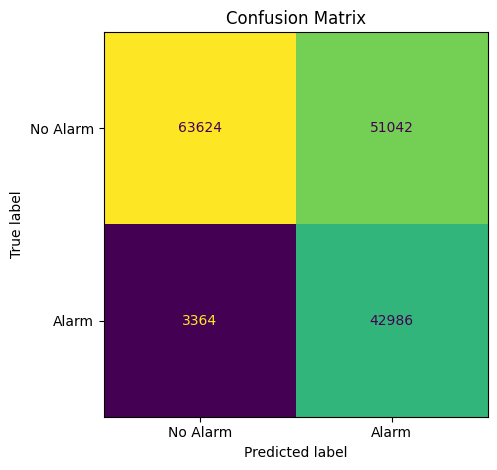

In [7]:
cm = confusion_matrix(y_test, y_pred_03)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

True Negatives (TN) — 63,624
True Positives (TP) — 42,986
False Negatives (FN) — 3,364
False Positives (FP) — 51,042

Recall ≈ 92.7%
This means that the model “catches” almost 93% of all alarms.

Precision ≈ 45.7%
Approximately every second alarm prediction comes true.

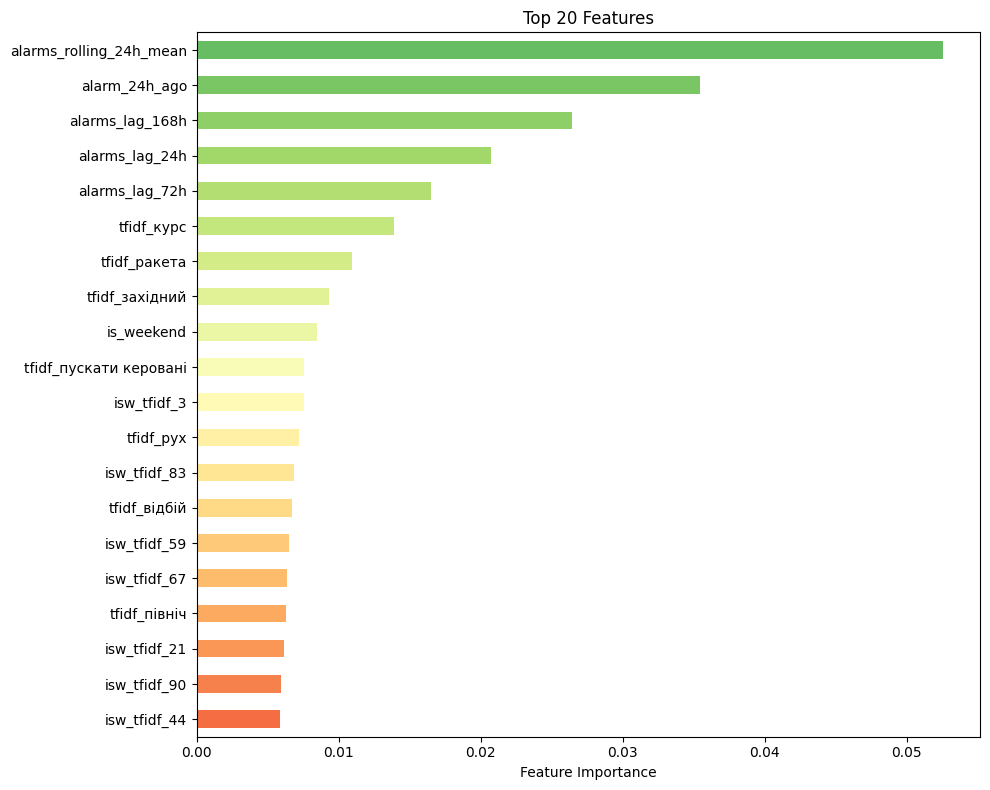

In [8]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [9]:
X_test.to_csv('test_data.csv', index=False)

In [10]:
with open('6__xgboost__v1.pkl', 'wb') as f:
    pickle.dump(model, f)

In [15]:
import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn

print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"xgboost=={xgb.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

pandas==3.0.1
numpy==2.4.2
xgboost==3.2.0
scikit-learn==1.8.0
